[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_2_MLR/17_2_1_9_MLR_exercise.ipynb)

# MLR Capstone Exercise: Predicting Fuel Economy in Classic Cars

Author: *Your name here*

**About this notebook.** This is a scaffolded exercise that asks you to apply everything you learned in the first five Ames Housing notebooks (`17_2_1_1` through `17_2_1_5`) to a brand-new dataset: the classic **Auto MPG** dataset, where the goal is to predict a vehicle's miles-per-gallon from its mechanical characteristics.

**What you will do.** Five Parts, mirroring the Ames series exactly:

| Part | Concept | Mirrors |
| :--- | :--- | :--- |
| 1 | Cleaning, imputation, log transforms, encoding | `17_2_1_1` |
| 2 | Forward / Backward selection and VIF | `17_2_1_2` |
| 3 | Ridge / Lasso / ElasticNet (with guessed alphas) | `17_2_1_3` |
| 4 | Hyperparameter tuning with GridSearchCV | `17_2_1_4` |
| 5 | Nested cross-validation and saving a production model | `17_2_1_5` |

**How to use this notebook.** Most of the code structure is given to you. Cells marked **`# YOUR TURN`** contain fill-in-the-blank tasks. Markdown cells marked **Reflection** ask you to write a short answer (1–3 sentences) interpreting the result. If you get stuck, open the corresponding Ames notebook and look at how the same operation was done there.

**Data Source:** UCI Auto MPG — `https://raw.githubusercontent.com/bsheese/cs377/main/data/data_auto_mpg.csv`


## 0. Setup

Run the cell below to import the libraries we will need across every part of this notebook.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)


### 0.1 Load the raw data

The cell below pulls the raw Auto MPG file from GitHub. Inspect the result. Pay particular attention to:
* The shape of the dataframe (how many rows, how many columns?)
* The dtype of `horsepower` — does anything look strange?
* Which columns look numeric? Which look categorical?


In [2]:
url = 'https://raw.githubusercontent.com/bsheese/cs377/main/data/data_auto_mpg.csv'
df = pd.read_csv(url)
print(f"Raw shape: {df.shape}")
df.head()


Raw shape: (398, 10)


,Unnamed: 0,mpg,cylinders,displacement,horsepower,weight,acceleration,modelyear,origin,carname
0,0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    398 non-null    int64  
 1   mpg           398 non-null    float64
 2   cylinders     398 non-null    int64  
 3   displacement  398 non-null    float64
 4   horsepower    398 non-null    str    
 5   weight        398 non-null    float64
 6   acceleration  398 non-null    float64
 7   modelyear     398 non-null    int64  
 8   origin        398 non-null    int64  
 9   carname       398 non-null    str    
dtypes: float64(4), int64(4), str(2)
memory usage: 39.4 KB


---
# Part 1 — Data Cleaning

Mirrors `17_2_1_1_MLR_Ames_Part1_Cleaning.ipynb`.

Our cleaning sequence will follow the same pattern as Ames:
1. Drop unhelpful columns
2. Convert "fake numeric" columns to their real type
3. Handle missing values (note: `?` is sometimes used to indicate missing!)
4. Train / test split **before** any statistical imputation
5. Median-impute numeric missing values (fit on train only)
6. Log-transform skewed numeric features and the target
7. Feature engineering
8. One-hot encode nominal categorical features


### 1.1 Drop the index column

The CSV has an unnamed leading column that is just a row index — it carries no information. Drop it.


In [4]:
df = df.drop(columns=['Unnamed: 0'])
df.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,modelyear,origin,carname
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


### 1.2 Fix the `horsepower` dtype  &nbsp; *(YOUR TURN)*

In the raw data, `horsepower` is stored as a *string* — the original UCI distribution used `'?'` to represent unknown values, and pandas reads the entire column as text as a result.

Convert `horsepower` to a numeric dtype. Any value that cannot be converted (the `'?'` strings) should become `NaN`.

**Hint:** `pd.to_numeric(..., errors='coerce')` converts unconvertible values to `NaN`.


In [5]:
# YOUR TURN: convert df['horsepower'] to numeric with errors='coerce'
# Uncomment the lines below, replace each ___ , and run the cell.
# df['horsepower'] = ___

# Check your work
# print(f"horsepower dtype: {df['horsepower'].dtype}")
# print(f"Number of missing horsepower values: {df['horsepower'].isna().sum()}")


In [6]:
# @title Execute to see solution
print("""
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
""")
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
print(f"horsepower dtype: {df['horsepower'].dtype}")
print(f"Number of missing horsepower values: {df['horsepower'].isna().sum()}")


df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

horsepower dtype: float64
Number of missing horsepower values: 6


### 1.3 Engineer `brand` from `carname`

`carname` is a free-text field — e.g. *"chevrolet chevelle malibu"*, *"ford pinto"*. The first token is the manufacturer (brand), and the rest is model trim. Treating each full carname as its own category would give us hundreds of dummy variables with only 1–2 rows each.

Instead, we extract the **brand** (first word) and drop the original `carname`. We also patch a few typos in the source data (e.g., `'toyouta'` → `'toyota'`).

Run the cell — this is given so you can focus on the modeling.


In [7]:
df['brand'] = df['carname'].str.split().str[0]

# Patch known typos in the source data
typo_fixes = {
    'chevroelt': 'chevrolet',
    'chevy': 'chevrolet',
    'maxda': 'mazda',
    'toyouta': 'toyota',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen',
    'mercedes': 'mercedes-benz',
}
df['brand'] = df['brand'].replace(typo_fixes)

# Collapse rare brands (≤2 cars) into 'other' so we do not get over-sparse dummies
brand_counts = df['brand'].value_counts()
rare_brands = brand_counts[brand_counts <= 2].index
df['brand'] = df['brand'].where(~df['brand'].isin(rare_brands), 'other')

df = df.drop(columns=['carname'])

print(f"Distinct brands kept: {df['brand'].nunique()}")
df['brand'].value_counts()


Distinct brands kept: 25


brand
ford             51
chevrolet        47
plymouth         31
amc              28
dodge            28
toyota           26
datsun           23
volkswagen       22
buick            17
pontiac          16
honda            13
mazda            12
mercury          11
oldsmobile       10
peugeot           8
other             8
fiat              8
audi              7
chrysler          6
volvo             6
renault           5
saab              4
opel              4
subaru            4
mercedes-benz     3
Name: count, dtype: int64

### 1.4 Treat coded integers as categorical

Some columns *look* numeric but are really category codes:

* `origin`: 1 = USA, 2 = Europe, 3 = Japan
* `modelyear`: the model year is a label, not a magnitude — a 1972 car is not "twice as much year" as a 1971 car
* `cylinders`: there are only a handful of distinct values and the relationship to MPG is not necessarily linear

If we leave these as integers, regression will treat them as continuous and impose a straight-line shape that may not exist. The safer choice is to convert them to strings now so they get one-hot encoded later. *(Compare this with Ames Part 1, where `MS SubClass` was given the same treatment.)*


In [8]:
for col in ['origin', 'modelyear', 'cylinders']:
    df[col] = df[col].astype(str)

df.dtypes


mpg             float64
cylinders           str
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
modelyear           str
origin              str
brand            object
dtype: object

### 1.5 Train / Test split

We split **before** any statistical imputation, so the medians we learn on the training set are not contaminated by test data. Use `random_state=42` for reproducibility.


In [9]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
print(f"Train shape: {df_train.shape}")
print(f"Test shape:  {df_test.shape}")


Train shape: (318, 9)
Test shape:  (80, 9)


### 1.6 Median imputation &nbsp; *(YOUR TURN)*

We have a handful of `NaN` values in `horsepower`. Use `SimpleImputer(strategy='median')` on the **numeric columns only**, **fit on `df_train`**, and apply the same imputer to `df_test`.

**Hint:** the Ames Part 1 notebook does this in the "Statistical Imputation" cell. The pattern is:

```python
imputer.fit_transform(df_train[numeric_cols])   # fit + transform train
imputer.transform(df_test[numeric_cols])        # transform test only
```


In [10]:
# numeric_cols = df_train.select_dtypes(include=np.number).columns
# Uncomment the lines below, replace each ___ , and run the cell.

# YOUR TURN: create the imputer, then fit_transform on train and transform on test
# imputer = ___
# df_train[numeric_cols] = ___
# df_test[numeric_cols] = ___

# print(f"Missing in train after imputation: {df_train.isna().sum().sum()}")
# print(f"Missing in test after imputation:  {df_test.isna().sum().sum()}")


In [11]:
# @title Execute to see solution
print("""
numeric_cols = df_train.select_dtypes(include=np.number).columns
imputer = SimpleImputer(strategy='median')
df_train[numeric_cols] = imputer.fit_transform(df_train[numeric_cols])
df_test[numeric_cols]  = imputer.transform(df_test[numeric_cols])
""")
numeric_cols = df_train.select_dtypes(include=np.number).columns
imputer = SimpleImputer(strategy='median')
df_train[numeric_cols] = imputer.fit_transform(df_train[numeric_cols])
df_test[numeric_cols]  = imputer.transform(df_test[numeric_cols])
print(f"Missing in train after imputation: {df_train.isna().sum().sum()}")
print(f"Missing in test after imputation:  {df_test.isna().sum().sum()}")


numeric_cols = df_train.select_dtypes(include=np.number).columns
imputer = SimpleImputer(strategy='median')
df_train[numeric_cols] = imputer.fit_transform(df_train[numeric_cols])
df_test[numeric_cols]  = imputer.transform(df_test[numeric_cols])

Missing in train after imputation: 0
Missing in test after imputation:  0


### 1.7 Log-transform skewed columns &nbsp; *(YOUR TURN)*

In Ames we log-transformed `Lot Area`, `Gr Liv Area`, `Mas Vnr Area`, and the target `SalePrice`, because they were right-skewed. Here we will log-transform:

* **The target** `mpg` — moderately right-skewed
* `displacement`, `horsepower`, `weight` — engine size and weight all have heavy right tails

Apply `np.log` to each column, save the result into a new column with a `Log_` prefix, and drop the original. Do this for **both `df_train` and `df_test`**.

**Hint:** loop over the column list and assign `df_train['Log_' + col] = np.log(df_train[col])`.


In [12]:
# skewed_cols = ['mpg', 'displacement', 'horsepower', 'weight']
# Uncomment the lines below, replace each ___ , and run the cell.

# YOUR TURN: for each col in skewed_cols, create Log_col on both train and test,
#            then drop the original column from both
# for col in skewed_cols:
#     df_train['Log_' + col] = ___
#     df_test['Log_' + col] = ___
#     df_train = df_train.drop(columns=col)
#     df_test = df_test.drop(columns=col)

# Quick visual check on the target
# fig, axes = plt.subplots(1, 1, figsize=(6, 3))
# sns.histplot(df_train['Log_mpg'], bins=25)
# plt.title('Distribution of Log(mpg) — should look roughly bell-shaped')
# plt.show()


In [13]:
# @title Execute to see solution
print("""
for col in skewed_cols:
    df_train['Log_' + col] = np.log(df_train[col])
    df_test['Log_' + col]  = np.log(df_test[col])
    df_train = df_train.drop(columns=col)
    df_test  = df_test.drop(columns=col)
""")
skewed_cols = ['mpg', 'displacement', 'horsepower', 'weight']
for col in skewed_cols:
    df_train['Log_' + col] = np.log(df_train[col])
    df_test['Log_' + col]  = np.log(df_test[col])
    df_train = df_train.drop(columns=col)
    df_test  = df_test.drop(columns=col)
print(f"New log columns: {[c for c in df_train.columns if c.startswith('Log_')]}")


for col in skewed_cols:
    df_train['Log_' + col] = np.log(df_train[col])
    df_test['Log_' + col]  = np.log(df_test[col])
    df_train = df_train.drop(columns=col)
    df_test  = df_test.drop(columns=col)

New log columns: ['Log_mpg', 'Log_displacement', 'Log_horsepower', 'Log_weight']


### 1.8 Feature engineering: power-to-weight ratio

In Ames we created `Total_Square_Footage`. Here, a natural domain-driven feature is **power-to-weight ratio** — heavy cars with weak engines are slow *and* inefficient.

Since we already log-transformed both, the difference `Log_horsepower - Log_weight` equals `log(horsepower / weight)`. We add this engineered feature without dropping the parents (regularization will sort out any redundancy in Part 3).


In [14]:
df_train['Log_power_to_weight'] = df_train['Log_horsepower'] - df_train['Log_weight']
df_test['Log_power_to_weight']  = df_test['Log_horsepower']  - df_test['Log_weight']
df_train.head()


,cylinders,acceleration,modelyear,origin,brand,Log_mpg,Log_displacement,Log_horsepower,Log_weight,Log_power_to_weight
3,8,12.0,70,1,amc,2.772589,5.717028,5.010635,8.141190,-3.130554
18,4,14.5,70,3,datsun,3.295837,4.574711,4.477337,7.663877,-3.186540
376,4,18.2,82,3,mazda,3.610918,4.510860,4.219508,7.613325,-3.393817
248,4,16.4,78,3,honda,3.586293,4.510860,4.094345,7.495542,-3.401197
177,4,15.0,75,2,audi,3.135494,4.744932,4.553877,7.898782,-3.344905


### 1.9 One-hot encode the nominal categoricals

We use `OneHotEncoder(drop='first', handle_unknown='ignore')` exactly like Ames Part 1 to avoid the dummy variable trap and to handle unseen categories gracefully at test time.


In [15]:
nominal_cols = df_train.select_dtypes(include=['object']).columns.tolist()
print(f"Encoding nominal columns: {nominal_cols}")

encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
encoded_train = encoder.fit_transform(df_train[nominal_cols])
encoded_test  = encoder.transform(df_test[nominal_cols])
encoded_cols  = encoder.get_feature_names_out(nominal_cols)

df_encoded_train = pd.DataFrame(encoded_train, columns=encoded_cols, index=df_train.index)
df_encoded_test  = pd.DataFrame(encoded_test,  columns=encoded_cols, index=df_test.index)

df_train = df_train.drop(columns=nominal_cols).join(df_encoded_train)
df_test  = df_test.drop(columns=nominal_cols).join(df_encoded_test)

print(f"Train shape after encoding: {df_train.shape}")


Encoding nominal columns: ['cylinders', 'modelyear', 'origin', 'brand']
Train shape after encoding: (318, 48)


### 1.10 Separate features (X) and target (y)


In [16]:
X_train = df_train.drop(columns='Log_mpg')
y_train = df_train['Log_mpg']
X_test  = df_test.drop(columns='Log_mpg')
y_test  = df_test['Log_mpg']

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")


X_train: (318, 47)  y_train: (318,)
X_test:  (80, 47)   y_test:  (80,)


**Reflection 1.** Why must median imputation be fit on the training set only? What concretely goes wrong if you fit it on the full dataframe before splitting?

*Your answer:*


---
# Part 2 — Forward / Backward Selection and VIF

Mirrors `17_2_1_2_MLR_Ames_Part2_ForwardBackward.ipynb`.

We have a few dozen features after one-hot encoding. Two complementary tools help us find the most useful ones:

* **Forward / Backward Selection** — searches the feature space using cross-validated $R^2$ improvement as the criterion.
* **VIF (Variance Inflation Factor)** — flags multicollinearity among the *selected* features.


### 2.1 Shortlist the top-correlated features &nbsp; *(YOUR TURN)*

`SequentialFeatureSelector` scales roughly as $O(\text{features}^2)$ during a forward search, so pre-filtering helps. Use the same trick as Ames Part 2: compute each feature's absolute correlation with `y_train`, sort, and keep the top 20.


In [17]:
# YOUR TURN: compute absolute correlations of every column in X_train with y_train
# Uncomment the lines below, replace each ___ , and run the cell.
# correlations = ___

# shortlist = correlations.head(20).index.tolist()

# print('Top 10 by |correlation| with Log_mpg:')
# print(correlations.head(10).to_string())

# X_train_short = X_train[shortlist]
# X_test_short  = X_test[shortlist]


In [18]:
# @title Execute to see solution
print("""
correlations = X_train.corrwith(y_train).abs().sort_values(ascending=False)
""")
correlations = X_train.corrwith(y_train).abs().sort_values(ascending=False)
shortlist = correlations.head(20).index.tolist()
X_train_short = X_train[shortlist]
X_test_short  = X_test[shortlist]
print('Top 10 by |correlation| with Log_mpg:')
print(correlations.head(10).to_string())


correlations = X_train.corrwith(y_train).abs().sort_values(ascending=False)

Top 10 by |correlation| with Log_mpg:
Log_weight          0.869149
Log_displacement    0.856934
Log_horsepower      0.839439
cylinders_4         0.780303
cylinders_8         0.705508
origin_3            0.427719
acceleration        0.415681
modelyear_80        0.341219
modelyear_73        0.290033
origin_2            0.284266


### 2.2 The selection helper

This is the same workflow you saw in Ames Part 2: a `Pipeline` of `StandardScaler` → `SequentialFeatureSelector` → `LinearRegression`, evaluated with `cross_validate` and refit on the full training data to extract the selected features and standardized coefficients.

Run the cell — no edits needed.


In [19]:
def perform_feature_selection_and_evaluation(X, y, direction='forward', cv_folds=5):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('selector', SequentialFeatureSelector(
            LinearRegression(),
            n_features_to_select='auto',
            direction=direction,
            cv=cv_folds,
        )),
        ('model', LinearRegression()),
    ])

    cv_results = cross_validate(pipeline, X, y, cv=cv_folds,
                                scoring=['r2'], return_train_score=True)

    pipeline.fit(X, y)
    selected_mask = pipeline.named_steps['selector'].get_support()
    selected_features = X.columns[selected_mask].tolist()
    coefs = pipeline.named_steps['model'].coef_

    coef_df = pd.DataFrame({'Feature': selected_features, 'Coefficient': coefs}) \
                .sort_values('Coefficient', ascending=False)

    print(f"--- {direction.upper()} SELECTION ---")
    print(f"Train R² (avg fold):  {cv_results['train_r2'].mean():.4f}")
    print(f"CV    R² (avg fold):  {cv_results['test_r2'].mean():.4f}")
    print(f"Train − CV gap:       {cv_results['train_r2'].mean() - cv_results['test_r2'].mean():+.4f}")
    print(f"Selected {len(selected_features)} of {X.shape[1]} candidate features.")
    return {'selected_features': selected_features, 'coefficients': coef_df, 'pipeline': pipeline}


### 2.3 Run forward selection


In [20]:
forward_results = perform_feature_selection_and_evaluation(
    X_train_short, y_train, direction='forward', cv_folds=5
)

print("\nTop coefficients (standardized):")
print(forward_results['coefficients'].head(10).to_string(index=False))


--- FORWARD SELECTION ---
Train R² (avg fold):  0.8902
CV    R² (avg fold):  0.8817
Train − CV gap:       +0.0085
Selected 10 of 20 candidate features.

Top coefficients (standardized):
       Feature  Coefficient
  modelyear_80     0.064060
  modelyear_82     0.049264
  modelyear_81     0.045148
   cylinders_4     0.043959
  brand_datsun     0.023190
    brand_ford    -0.022544
  acceleration    -0.036029
  modelyear_73    -0.039495
    Log_weight    -0.107352
Log_horsepower    -0.146912


### 2.4 Run backward selection &nbsp; *(YOUR TURN)*

Repeat the call, but with `direction='backward'`.


In [21]:
# YOUR TURN: call the helper with direction='backward'
# Uncomment the lines below, replace each ___ , and run the cell.
# backward_results = ___

# print("\nTop coefficients (standardized):")
# print(backward_results['coefficients'].head(10).to_string(index=False))


In [22]:
# @title Execute to see solution
print("""
backward_results = perform_feature_selection_and_evaluation(
    X_train_short, y_train, direction='backward', cv_folds=5
)
""")
backward_results = perform_feature_selection_and_evaluation(
    X_train_short, y_train, direction='backward', cv_folds=5
)
print("\nTop coefficients (standardized):")
print(backward_results['coefficients'].head(10).to_string(index=False))


backward_results = perform_feature_selection_and_evaluation(
    X_train_short, y_train, direction='backward', cv_folds=5
)



--- BACKWARD SELECTION ---
Train R² (avg fold):  0.8905
CV    R² (avg fold):  0.8831
Train − CV gap:       +0.0073
Selected 10 of 20 candidate features.

Top coefficients (standardized):
            Feature  Coefficient
Log_power_to_weight     0.065643
       modelyear_80     0.064060
       modelyear_82     0.049264
       modelyear_81     0.045148
        cylinders_4     0.043959
       brand_datsun     0.023190
         brand_ford    -0.022544
       acceleration    -0.036029
       modelyear_73    -0.039495
     Log_horsepower    -0.275291


**Reflection 2.1.** Do forward and backward selection agree on which features matter? List one feature kept by both, one kept by only one of them (if any), and propose a reason.

*Your answer:*


### 2.5 VIF — Variance Inflation Factor

VIF tells us whether two or more features carry essentially the *same* signal. A rule of thumb:

| VIF | Interpretation |
| :--- | :--- |
| ~1   | No collinearity |
| 1–5  | Mild |
| 5–10 | Moderate — investigate |
| > 10 | Severe — drop one |

Run VIF on the **continuous / ordinal** subset of the backward-selected features (skipping the 0/1 dummies, which inflate VIF spuriously).


In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X):
    X_with_const = X.assign(const=1)
    rows = []
    for i, col in enumerate(X.columns):
        rows.append({'Feature': col, 'VIF': variance_inflation_factor(X_with_const.values, i)})
    return pd.DataFrame(rows).sort_values('VIF', ascending=False)

selected = backward_results['selected_features']
numeric_selected = [f for f in selected if X_train[f].nunique() > 2]

print(f"Computing VIF on {len(numeric_selected)} continuous features...")
calculate_vif(X_train[numeric_selected])


Computing VIF on 3 continuous features...


,Feature,VIF
1,acceleration,2.809145
2,Log_power_to_weight,2.173957
0,Log_horsepower,1.873445


**Reflection 2.2.** Look at the VIF table above. Which two features look most collinear? Given what you know about cars, why does that make physical sense? Which one would you drop and why?

*Your answer:*


---
# Part 3 — Regularization (Ridge / Lasso / ElasticNet)

Mirrors `17_2_1_3_MLR_Ames_Part3_Regularization.ipynb`.

Rather than hand-prune collinear features, we will now lean on regularization. We will:
1. Build an evaluation pipeline that reports MAE **in real MPG units** (reversing the log transform — the "Log-Dollar Illusion" fix from Ames Part 3, here a "Log-MPG Illusion" fix).
2. Score OLS, Ridge, Lasso, and ElasticNet with hand-picked alpha values.
3. Visualize the most important coefficients.


### 3.1 The evaluation pipeline

Identical pattern to Ames Part 3 — `StandardScaler` + the regressor inside a `Pipeline`, scored with 5-fold CV. Predictions are inverse-log-transformed back to MPG before computing the MAE.


In [24]:
def run_evaluation_pipeline(model, X, y, model_name='Model'):
    pipe = Pipeline([('scaler', StandardScaler()), ('regressor', model)])

    cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='neg_mean_squared_error')
    cv_rmse_log = np.sqrt(-cv_scores.mean())

    log_cv_preds = cross_val_predict(pipe, X, y, cv=5)
    real_cv_preds = np.exp(log_cv_preds)
    real_y = np.exp(y)

    mae_mpg = mean_absolute_error(real_y, real_cv_preds)
    rmse_mpg = np.sqrt(mean_squared_error(real_y, real_cv_preds))

    pipe.fit(X, y)

    print(f"--- {model_name} (CV validation) ---")
    print(f"CV Log-RMSE:      {cv_rmse_log:.4f}")
    print(f"Real-MPG MAE:     {mae_mpg:.3f} mpg")
    print(f"Real-MPG RMSE:    {rmse_mpg:.3f} mpg")
    print('-' * 38)

    return pipe, mae_mpg


### 3.2 OLS baseline

We use the *full* feature set `X_train` here (not the shortlist) so that regularization has something to push against — there are ~50+ columns after one-hot encoding.


In [25]:
ols_pipe, ols_mae = run_evaluation_pipeline(LinearRegression(), X_train, y_train, 'OLS Baseline')


--- OLS Baseline (CV validation) ---
CV Log-RMSE:      0.1163
Real-MPG MAE:     2.035 mpg
Real-MPG RMSE:    2.886 mpg
--------------------------------------


### 3.3 Ridge with a guessed alpha &nbsp; *(YOUR TURN)*

Pick any `alpha` value you like to start (Ames used `alpha=100` for Ridge — try something similar). We will tune the real number in Part 4.


In [26]:
# YOUR TURN: choose an alpha value for Ridge
# Uncomment the lines below, replace each ___ , and run the cell.
# ridge_alpha_guess = ___
# ridge_pipe, ridge_mae = run_evaluation_pipeline(Ridge(alpha=ridge_alpha_guess), X_train, y_train, 'Ridge (guess)')


In [27]:
# @title Execute to see solution
print("""
ridge_alpha_guess = 100   # any value 10–500 is reasonable; we tune exactly in Part 4
""")
ridge_alpha_guess = 100
ridge_pipe, ridge_mae = run_evaluation_pipeline(
    Ridge(alpha=ridge_alpha_guess), X_train, y_train, 'Ridge (guess)'
)


ridge_alpha_guess = 100   # any value 10–500 is reasonable; we tune exactly in Part 4

--- Ridge (guess) (CV validation) ---
CV Log-RMSE:      0.1264
Real-MPG MAE:     2.189 mpg
Real-MPG RMSE:    3.160 mpg
--------------------------------------


### 3.4 Lasso with a guessed alpha &nbsp; *(YOUR TURN)*

Lasso is much more sensitive to alpha than Ridge — Ames used `alpha=0.005`. Try something **small**.


In [28]:
# YOUR TURN: choose an alpha value for Lasso (very small)
# Uncomment the lines below, replace each ___ , and run the cell.
# lasso_alpha_guess = ___
# lasso_pipe, lasso_mae = run_evaluation_pipeline(Lasso(alpha=lasso_alpha_guess, max_iter=10000),
#                                                 X_train, y_train, 'Lasso (guess)')

# lasso_coefs = lasso_pipe.named_steps['regressor'].coef_
# print(f"Lasso kept {int((lasso_coefs != 0).sum())} of {X_train.shape[1]} features.")


In [29]:
# @title Execute to see solution
print("""
lasso_alpha_guess = 0.005   # Lasso needs a very small alpha; 0.001–0.01 is typical
""")
lasso_alpha_guess = 0.005
lasso_pipe, lasso_mae = run_evaluation_pipeline(
    Lasso(alpha=lasso_alpha_guess, max_iter=10000), X_train, y_train, 'Lasso (guess)'
)
lasso_coefs = lasso_pipe.named_steps['regressor'].coef_
print(f"Lasso kept {int((lasso_coefs != 0).sum())} of {X_train.shape[1]} features.")


lasso_alpha_guess = 0.005   # Lasso needs a very small alpha; 0.001–0.01 is typical

--- Lasso (guess) (CV validation) ---
CV Log-RMSE:      0.1114
Real-MPG MAE:     1.949 mpg
Real-MPG RMSE:    2.765 mpg
--------------------------------------
Lasso kept 28 of 47 features.


### 3.5 Elastic Net with guessed alpha + l1_ratio


In [30]:
en_pipe, en_mae = run_evaluation_pipeline(
    ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000),
    X_train, y_train, 'ElasticNet (guess)'
)


--- ElasticNet (guess) (CV validation) ---
CV Log-RMSE:      0.1117
Real-MPG MAE:     1.951 mpg
Real-MPG RMSE:    2.773 mpg
--------------------------------------


### 3.6 Compare the four models


In [31]:
results = pd.DataFrame({
    'Model': ['OLS', 'Ridge', 'Lasso', 'ElasticNet'],
    'MAE (mpg)': [ols_mae, ridge_mae, lasso_mae, en_mae],
}).sort_values('MAE (mpg)').reset_index(drop=True)

display(results.style.format({'MAE (mpg)': '{:.3f}'}))


,Model,MAE (mpg)
0,Lasso,1.949
1,ElasticNet,1.951
2,OLS,2.035
3,Ridge,2.189


### 3.7 Top "movers" — Ridge standardized coefficients


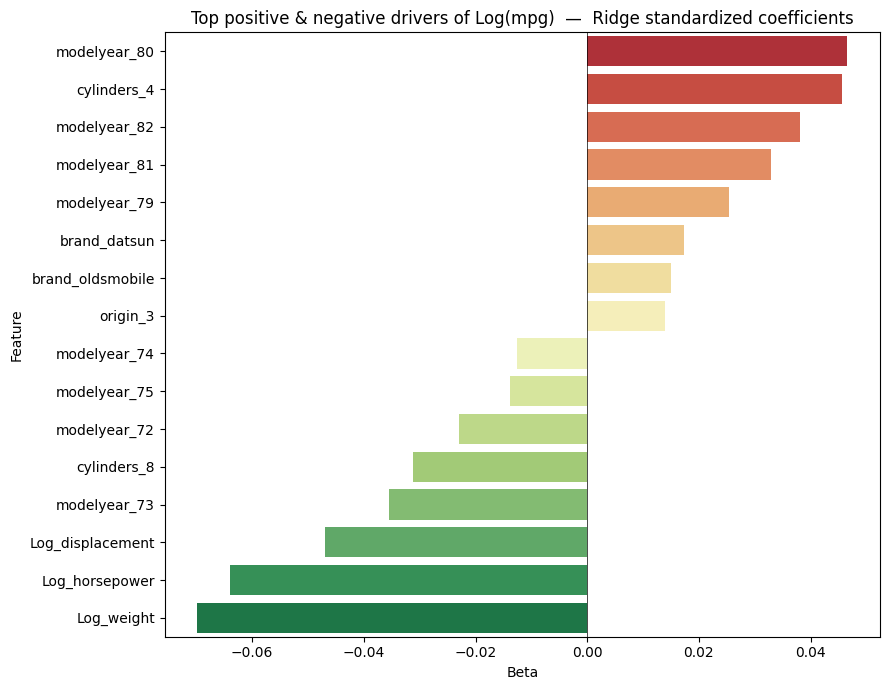

In [32]:
coefs = pd.DataFrame({
    'Feature': X_train.columns,
    'Beta': ridge_pipe.named_steps['regressor'].coef_,
}).sort_values('Beta', ascending=False)

top_bottom = pd.concat([coefs.head(8), coefs.tail(8)])

plt.figure(figsize=(9, 7))
sns.barplot(data=top_bottom, x='Beta', y='Feature', palette='RdYlGn')
plt.title('Top positive & negative drivers of Log(mpg)  —  Ridge standardized coefficients')
plt.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()


**Reflection 3.** Which model has the lowest MAE on the validation folds? Does that match what happened on Ames in Part 3? Why might Lasso fall behind on this dataset specifically?

*Your answer:*


---
# Part 4 — Hyperparameter Tuning

Mirrors `17_2_1_4_MLR_Ames_Part4_HyperparameterTuning.ipynb`.

We stop guessing. We will:
1. Manually loop over alphas for **Ridge** to *see* the bias-variance tradeoff.
2. Use `GridSearchCV` to tune Ridge, Lasso, and ElasticNet automatically.
3. Evaluate every tuned model on the locked-away test set.


### 4.1 The validation curve — see the tradeoff &nbsp; *(YOUR TURN)*

Loop over a grid of alphas spanning many orders of magnitude. Record validation MAE and in-sample training MAE for each. Then plot both curves on a log-x axis.


In [33]:
# YOUR TURN: fill in a list of alphas spanning at least 5 orders of magnitude
# Uncomment the lines below, replace each ___ , and run the cell.
# alphas = ___

# cv_mae_list = []
# train_mae_list = []

# for a in alphas:
#     pipe, cv_mae = run_evaluation_pipeline(Ridge(alpha=a), X_train, y_train, f"Ridge (a={a})")
#     cv_mae_list.append(cv_mae)
#     train_mae_list.append(mean_absolute_error(np.exp(y_train), np.exp(pipe.predict(X_train))))

# plt.figure(figsize=(9, 5))
# plt.plot(alphas, cv_mae_list, marker='o', label='CV Validation MAE')
# plt.plot(alphas, train_mae_list, marker='o', label='In-Sample Train MAE')
# plt.xscale('log')
# plt.xlabel('Alpha (penalty strength)')
# plt.ylabel('MAE (mpg)')
# plt.title('Bias–Variance tradeoff for Ridge regression')
# plt.legend()
# plt.grid(True, which='both', linewidth=0.3)
# plt.show()


In [34]:
# @title Execute to see solution
print("""
alphas = np.logspace(-3, 4, 20)   # 20 points spanning 0.001 → 10,000 (7 orders of magnitude)
""")
alphas = np.logspace(-3, 4, 20)
print(f"Alpha range: {alphas[0]:.4f} – {alphas[-1]:.0f}  ({len(alphas)} values)")


alphas = np.logspace(-3, 4, 20)   # 20 points spanning 0.001 → 10,000 (7 orders of magnitude)

Alpha range: 0.0010 – 10000  (20 values)


### 4.2 GridSearchCV — Ridge


In [35]:
ridge_pipeline = Pipeline([('scaler', StandardScaler()), ('regressor', Ridge())])

param_grid_ridge = {'regressor__alpha': np.logspace(-3, 4, 100)}

ridge_grid = GridSearchCV(ridge_pipeline, param_grid_ridge, cv=5,
                          scoring='neg_mean_squared_error', refit=True, n_jobs=-1)
ridge_grid.fit(X_train, y_train)

best_ridge_alpha = ridge_grid.best_params_['regressor__alpha']
print(f"Optimal Ridge alpha: {best_ridge_alpha:.4f}")

tuned_ridge = Ridge(alpha=best_ridge_alpha)
_, tuned_ridge_mae = run_evaluation_pipeline(tuned_ridge, X_train, y_train, 'Tuned Ridge')


Optimal Ridge alpha: 2.9151
--- Tuned Ridge (CV validation) ---
CV Log-RMSE:      0.1137
Real-MPG MAE:     1.972 mpg
Real-MPG RMSE:    2.820 mpg
--------------------------------------


### 4.3 GridSearchCV — Lasso &nbsp; *(YOUR TURN)*

Build a similar grid for Lasso. Remember: Lasso's optimal alpha is usually much smaller than Ridge's.


In [36]:
# lasso_pipeline = Pipeline([('scaler', StandardScaler()), ('regressor', Lasso(max_iter=10000))])
# Uncomment the lines below, replace each ___ , and run the cell.

# YOUR TURN: define a grid of alphas appropriate for Lasso (try np.logspace with a small range)
# param_grid_lasso = {'regressor__alpha': ___}

# lasso_grid = GridSearchCV(lasso_pipeline, param_grid_lasso, cv=5,
#                           scoring='neg_mean_squared_error', refit=True, n_jobs=-1)
# lasso_grid.fit(X_train, y_train)

# best_lasso_alpha = lasso_grid.best_params_['regressor__alpha']
# print(f"Optimal Lasso alpha: {best_lasso_alpha:.5f}")

# tuned_lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000)
# _, tuned_lasso_mae = run_evaluation_pipeline(tuned_lasso, X_train, y_train, 'Tuned Lasso')

# kept = int((lasso_grid.best_estimator_.named_steps['regressor'].coef_ != 0).sum())
# print(f"Tuned Lasso kept {kept} of {X_train.shape[1]} features.")


In [37]:
# @title Execute to see solution
print("""
lasso_pipeline  = Pipeline([('scaler', StandardScaler()), ('regressor', Lasso(max_iter=10000))])
param_grid_lasso = {'regressor__alpha': np.logspace(-5, 0, 50)}
""")
lasso_pipeline  = Pipeline([('scaler', StandardScaler()), ('regressor', Lasso(max_iter=10000))])
param_grid_lasso = {'regressor__alpha': np.logspace(-5, 0, 50)}
lasso_grid = GridSearchCV(lasso_pipeline, param_grid_lasso, cv=5,
                          scoring='neg_mean_squared_error', refit=True, n_jobs=-1)
lasso_grid.fit(X_train, y_train)
best_lasso_alpha = lasso_grid.best_params_['regressor__alpha']
print(f"Optimal Lasso alpha: {best_lasso_alpha:.5f}")
tuned_lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000)
_, tuned_lasso_mae = run_evaluation_pipeline(tuned_lasso, X_train, y_train, 'Tuned Lasso')
kept = int((lasso_grid.best_estimator_.named_steps['regressor'].coef_ != 0).sum())
print(f"Tuned Lasso kept {kept} of {X_train.shape[1]} features.")


lasso_pipeline  = Pipeline([('scaler', StandardScaler()), ('regressor', Lasso(max_iter=10000))])
param_grid_lasso = {'regressor__alpha': np.logspace(-5, 0, 50)}



Optimal Lasso alpha: 0.00281


--- Tuned Lasso (CV validation) ---
CV Log-RMSE:      0.1108
Real-MPG MAE:     1.937 mpg
Real-MPG RMSE:    2.755 mpg
--------------------------------------
Tuned Lasso kept 32 of 47 features.


### 4.4 GridSearchCV — ElasticNet (2-D)

This is a true 2-D grid search across `alpha` and `l1_ratio`. Notice the cost: with 30 × 7 combinations × 5 folds = 1,050 model fits.


In [38]:
en_pipeline = Pipeline([('scaler', StandardScaler()), ('regressor', ElasticNet(max_iter=10000))])

param_grid_en = {
    'regressor__alpha':    np.logspace(-4, 1, 30),
    'regressor__l1_ratio': [0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 0.99],
}

en_grid = GridSearchCV(en_pipeline, param_grid_en, cv=5,
                       scoring='neg_mean_squared_error', refit=True, n_jobs=-1)
en_grid.fit(X_train, y_train)

best_en_alpha = en_grid.best_params_['regressor__alpha']
best_en_ratio = en_grid.best_params_['regressor__l1_ratio']
print(f"Optimal ElasticNet alpha:    {best_en_alpha:.5f}")
print(f"Optimal ElasticNet l1_ratio: {best_en_ratio}")

tuned_en = ElasticNet(alpha=best_en_alpha, l1_ratio=best_en_ratio, max_iter=10000)
_, tuned_en_mae = run_evaluation_pipeline(tuned_en, X_train, y_train, 'Tuned ElasticNet')


Optimal ElasticNet alpha:    0.00356
Optimal ElasticNet l1_ratio: 0.9
--- Tuned ElasticNet (CV validation) ---
CV Log-RMSE:      0.1108
Real-MPG MAE:     1.936 mpg
Real-MPG RMSE:    2.755 mpg
--------------------------------------


### 4.5 Final test set evaluation


In [39]:
def evaluate_on_test(model, X_train, y_train, X_test, y_test):
    pipe = Pipeline([('scaler', StandardScaler()), ('regressor', model)])
    pipe.fit(X_train, y_train)
    preds_log = pipe.predict(X_test)
    return mean_absolute_error(np.exp(y_test), np.exp(preds_log))

test_mae_ols   = evaluate_on_test(LinearRegression(), X_train, y_train, X_test, y_test)
test_mae_ridge = evaluate_on_test(tuned_ridge, X_train, y_train, X_test, y_test)
test_mae_lasso = evaluate_on_test(tuned_lasso, X_train, y_train, X_test, y_test)
test_mae_en    = evaluate_on_test(tuned_en,    X_train, y_train, X_test, y_test)

_, ols_cv_mae = run_evaluation_pipeline(LinearRegression(), X_train, y_train, 'OLS (recap)')

final_table = pd.DataFrame({
    'Model':                ['OLS', 'Tuned Ridge', 'Tuned Lasso', 'Tuned ElasticNet'],
    'CV MAE (train)':       [ols_cv_mae, tuned_ridge_mae, tuned_lasso_mae, tuned_en_mae],
    'Test MAE (unseen)':    [test_mae_ols, test_mae_ridge, test_mae_lasso, test_mae_en],
})
final_table['Performance Drop'] = final_table['Test MAE (unseen)'] - final_table['CV MAE (train)']

display(final_table.style.format({
    'CV MAE (train)':    '{:.3f}',
    'Test MAE (unseen)': '{:.3f}',
    'Performance Drop':  '{:+.3f}',
}))


--- OLS (recap) (CV validation) ---
CV Log-RMSE:      0.1163
Real-MPG MAE:     2.035 mpg
Real-MPG RMSE:    2.886 mpg
--------------------------------------


,Model,CV MAE (train),Test MAE (unseen),Performance Drop
0,OLS,2.035,1.932,-0.104
1,Tuned Ridge,1.972,1.873,-0.099
2,Tuned Lasso,1.937,1.759,-0.178
3,Tuned ElasticNet,1.936,1.747,-0.188


**Reflection 4.** Look at the "Performance Drop" column. Is the test-set MAE close to the CV-validation MAE, or noticeably worse? If you compared three tuned models against the same test set, what subtle bias might you have introduced by picking the "winner" that way? *(This is the motivation for Part 5.)*

*Your answer:*


---
# Part 5 — Nested Cross-Validation and a Production Model

Mirrors `17_2_1_5_MLR_Ames_Part5_NestedCV.ipynb`.

In Part 4 we compared three tuned models against the same held-out test set. Every comparison leaks a tiny bit of test-set information into the choice of "winning" model — the more comparisons, the more optimistic the winner looks.

**Nested CV** removes that bias by replacing the single held-out test set with two nested CV loops:

* **Inner loop** = `GridSearchCV` chooses the best alpha for each outer training fold.
* **Outer loop** = `cross_val_predict` evaluates the *whole pipeline* (including the inner grid search) on data it has never touched.

Crucially: nested CV is an **evaluation tool**, not a deployment tool. It gives you a trustworthy performance number. To get a deployable model, you re-run grid search on 100% of your data afterward.


### 5.1 Combine train + test into a single dataset

Since nested CV evaluates the entire pipeline (including hyperparameter selection) end-to-end, we no longer need a held-out test set. We feed it 100% of the data.


In [40]:
X = pd.concat([X_train, X_test])
y = pd.concat([y_train, y_test])
print(f"Full dataset for nested CV: {X.shape}")


Full dataset for nested CV: (398, 47)


### 5.2 Run nested CV &nbsp; *(YOUR TURN)*

Build a `GridSearchCV` over Ridge alphas (the inner loop), then pass it as the estimator to `cross_val_predict` with `cv=5` (the outer loop).


In [41]:
# ridge_pipeline_nested = Pipeline([('scaler', StandardScaler()), ('regressor', Ridge())])
# Uncomment the lines below, replace each ___ , and run the cell.
# param_grid_nested = {'regressor__alpha': np.logspace(-3, 4, 100)}

# Inner loop
# inner_loop_cv = GridSearchCV(
#     estimator=ridge_pipeline_nested,
#     param_grid=param_grid_nested,
#     cv=5,
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,
# )

# YOUR TURN: outer loop — call cross_val_predict on the FULL X, y, passing inner_loop_cv as estimator
# print('Running nested cross-validation...')
# nested_log_preds = ___

# nested_real_preds = np.exp(nested_log_preds)
# real_y = np.exp(y)

# nested_mae  = mean_absolute_error(real_y, nested_real_preds)
# nested_rmse = np.sqrt(mean_squared_error(real_y, nested_real_preds))

# print('-' * 40)
# print(f"Nested CV MAE:  {nested_mae:.3f} mpg")
# print(f"Nested CV RMSE: {nested_rmse:.3f} mpg")


In [42]:
# @title Execute to see solution
print("""
ridge_pipeline_nested = Pipeline([('scaler', StandardScaler()), ('regressor', Ridge())])
param_grid_nested = {'regressor__alpha': np.logspace(-3, 4, 100)}
inner_loop_cv = GridSearchCV(ridge_pipeline_nested, param_grid_nested, cv=5,
                             scoring='neg_mean_squared_error', n_jobs=-1)
nested_log_preds = cross_val_predict(inner_loop_cv, X, y, cv=5, n_jobs=-1)
""")
ridge_pipeline_nested = Pipeline([('scaler', StandardScaler()), ('regressor', Ridge())])
param_grid_nested = {'regressor__alpha': np.logspace(-3, 4, 100)}
inner_loop_cv = GridSearchCV(ridge_pipeline_nested, param_grid_nested, cv=5,
                             scoring='neg_mean_squared_error', n_jobs=-1)
nested_log_preds = cross_val_predict(inner_loop_cv, X, y, cv=5, n_jobs=-1)
nested_real_preds = np.exp(nested_log_preds)
real_y = np.exp(y)
nested_mae  = mean_absolute_error(real_y, nested_real_preds)
nested_rmse = np.sqrt(mean_squared_error(real_y, nested_real_preds))
print('-' * 40)
print(f"Nested CV MAE:  {nested_mae:.3f} mpg")
print(f"Nested CV RMSE: {nested_rmse:.3f} mpg")


ridge_pipeline_nested = Pipeline([('scaler', StandardScaler()), ('regressor', Ridge())])
param_grid_nested = {'regressor__alpha': np.logspace(-3, 4, 100)}
inner_loop_cv = GridSearchCV(ridge_pipeline_nested, param_grid_nested, cv=5,
                             scoring='neg_mean_squared_error', n_jobs=-1)
nested_log_preds = cross_val_predict(inner_loop_cv, X, y, cv=5, n_jobs=-1)



----------------------------------------
Nested CV MAE:  1.937 mpg
Nested CV RMSE: 2.766 mpg


### 5.3 Inspect the winning alphas across outer folds

`cross_validate(..., return_estimator=True)` keeps the 5 fitted inner `GridSearchCV` objects so we can inspect them.


In [43]:
nested_results = cross_validate(
    estimator=inner_loop_cv,
    X=X, y=y,
    cv=5,
    return_estimator=True,
    n_jobs=-1,
)

print('Alphas chosen by the inner loop across the 5 outer folds:')
for i, gs in enumerate(nested_results['estimator']):
    print(f"  Outer fold {i+1}: alpha = {gs.best_params_['regressor__alpha']:.4f}")


Alphas chosen by the inner loop across the 5 outer folds:
  Outer fold 1: alpha = 2.9151
  Outer fold 2: alpha = 2.9151
  Outer fold 3: alpha = 4.0370
  Outer fold 4: alpha = 2.1049
  Outer fold 5: alpha = 2.4771


**Reflection 5.1.** Are the winning alphas clustered together or all over the place? What would each interpretation tell you about the stability of your modelling pipeline?

*Your answer:*


### 5.4 Train the final production model on 100% of the data

Nested CV gave us an *unbiased estimate*. Now we forget about evaluation and just train the best-possible model on all the data we have.


In [44]:
print('Fitting final production grid search on 100% of the data...')
final_grid = inner_loop_cv.fit(X, y)

final_alpha = final_grid.best_params_['regressor__alpha']
print(f"Final production alpha: {final_alpha:.4f}")

final_pipeline = final_grid.best_estimator_
final_ridge    = final_pipeline.named_steps['regressor']

final_coefs = pd.DataFrame({'Feature': X.columns, 'Beta': final_ridge.coef_})
top_drivers = final_coefs.reindex(final_coefs['Beta'].abs().sort_values(ascending=False).index).head(8)
print('\nTop 8 drivers of fuel economy in the production model:')
print(top_drivers.to_string(index=False))


Fitting final production grid search on 100% of the data...


Final production alpha: 4.0370

Top 8 drivers of fuel economy in the production model:
       Feature      Beta
    Log_weight -0.134876
Log_horsepower -0.112609
  modelyear_80  0.077885
  modelyear_82  0.074978
   cylinders_4  0.067347
  modelyear_81  0.058562
  modelyear_79  0.051301
   cylinders_8  0.035902


### 5.5 Save the model for deployment

In a real project this `.pkl` file would be loaded by a web app, a batch scoring job, or another script.


In [45]:
import joblib

model_filename = 'auto_mpg_production_ridge_model.pkl'
joblib.dump(final_pipeline, model_filename)
print(f"Production model saved to: {model_filename}")


Production model saved to: auto_mpg_production_ridge_model.pkl


**Reflection 5.2.** Suppose a stakeholder asks: *"How well will this model do on cars it has never seen?"* Which single number from this notebook is the most intellectually honest answer? Why is it preferable to the "test MAE" from Part 4?

*Your answer:*


---
# Part 6 — Learning Curves: How Much Data Is Enough?

> **Prerequisites:** Run Parts 1–4 of this notebook first. This Part uses `X_train`, `y_train`, and `best_ridge_alpha` defined in those earlier Parts.

Mirrors the learning-curve analysis introduced in `17_2_1_4_MLR_Ames_Part4_HyperparameterTuning.ipynb`.

So far we have tuned *hyperparameters* (alpha). A complementary question is: *how sensitive is our model to the amount of training data?*

A **learning curve** plots training error and cross-validated validation error as a function of training set size. Two characteristic shapes:

| Shape | Meaning |
|-------|---------|
| Large gap between train and validation | **High variance** — model would benefit from more data |
| Both curves plateau and converge | **High bias** (or data-saturated) — more data won't help much |

We will use `sklearn.model_selection.learning_curve` with the tuned Ridge alpha from Part 4.

### 6.1 Import and configure &nbsp; *(YOUR TURN)*

Import `learning_curve` and define the training-size grid.

In [46]:
# from sklearn.model_selection import learning_curve
# Uncomment the lines below, replace each ___ , and run the cell.
# from sklearn.linear_model import Ridge
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# import numpy as np
# import matplotlib.pyplot as plt

# YOUR TURN: define a list or array of 8 training-set sizes evenly spaced
#            from 50 rows to 250 rows. (With cv=5, only 4/5 of X_train —
#            about 254 rows — is available for fitting in each fold.)
# train_sizes = np.linspace(___, ___, ___, dtype=int)
# print(f'Training sizes to test: {train_sizes}')

In [47]:
# @title Execute to see solution
print("""
train_sizes = np.linspace(50, 250, 8, dtype=int)
""")
train_sizes = np.linspace(50, 250, 8, dtype=int)
print(f'Training sizes to test: {train_sizes}')


train_sizes = np.linspace(50, 250, 8, dtype=int)

Training sizes to test: [ 50  78 107 135 164 192 221 250]


### 6.2 Run the learning curve &nbsp; *(YOUR TURN)*

Call `learning_curve` with the tuned Ridge model (use `best_ridge_alpha` from Part 4) inside a StandardScaler pipeline, and 5-fold CV.

In [48]:
# YOUR TURN: build the pipeline and call learning_curve
# Uncomment the lines below, replace each ___ , and run the cell.
# ridge_lc_pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('regressor', Ridge(alpha=___)),   # fill in best_ridge_alpha
# ])

# sizes_out, train_scores, val_scores = learning_curve(
#     estimator=___,
#     X=X_train, y=y_train,
#     train_sizes=train_sizes,
#     cv=5,
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,
# )

# Convert from negative MSE to RMSE in log-space
# train_rmse = np.sqrt(-train_scores.mean(axis=1))
# val_rmse   = np.sqrt(-val_scores.mean(axis=1))
# val_std    = np.sqrt(-val_scores).std(axis=1)

# print('Training sizes:', sizes_out)
# print('Train RMSE:    ', np.round(train_rmse, 4))
# print('Val   RMSE:    ', np.round(val_rmse, 4))

In [49]:
# @title Execute to see solution
print("""
from sklearn.model_selection import learning_curve

ridge_lc_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', Ridge(alpha=best_ridge_alpha)),
])

sizes_out, train_scores, val_scores = learning_curve(
    estimator=ridge_lc_pipeline,
    X=X_train, y=y_train,
    train_sizes=train_sizes,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
)
""")
from sklearn.model_selection import learning_curve
ridge_lc_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', Ridge(alpha=best_ridge_alpha)),
])
sizes_out, train_scores, val_scores = learning_curve(
    estimator=ridge_lc_pipeline,
    X=X_train, y=y_train,
    train_sizes=train_sizes,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
)
train_rmse = np.sqrt(-train_scores.mean(axis=1))
val_rmse   = np.sqrt(-val_scores.mean(axis=1))
val_std    = np.sqrt(-val_scores).std(axis=1)
print('Training sizes:', sizes_out)
print('Train RMSE:    ', np.round(train_rmse, 4))
print('Val   RMSE:    ', np.round(val_rmse, 4))


from sklearn.model_selection import learning_curve

ridge_lc_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', Ridge(alpha=best_ridge_alpha)),
])

sizes_out, train_scores, val_scores = learning_curve(
    estimator=ridge_lc_pipeline,
    X=X_train, y=y_train,
    train_sizes=train_sizes,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
)

Training sizes: [ 50  78 107 135 164 192 221 250]
Train RMSE:     [0.0438 0.0613 0.0721 0.0834 0.0836 0.0853 0.0875 0.087 ]
Val   RMSE:     [0.1566 0.1406 0.1346 0.1289 0.1271 0.1178 0.1164 0.1162]


### 6.3 Plot

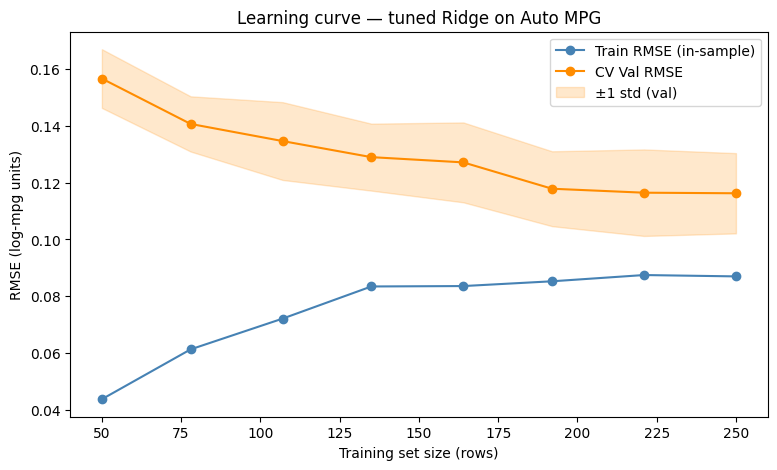

In [50]:
# Given — plot the two curves
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sizes_out, train_rmse, marker='o', label='Train RMSE (in-sample)', color='steelblue')
ax.plot(sizes_out, val_rmse,   marker='o', label='CV Val RMSE',            color='darkorange')
ax.fill_between(sizes_out,
                val_rmse - val_std, val_rmse + val_std,
                alpha=0.2, color='darkorange', label='±1 std (val)')
ax.set_xlabel('Training set size (rows)')
ax.set_ylabel('RMSE (log-mpg units)')
ax.set_title('Learning curve — tuned Ridge on Auto MPG')
ax.legend()
plt.show()

**Reflection 6.** Answer both questions below in 1–2 sentences.

1. **Gap analysis.** Is there a large gap between training RMSE and validation RMSE at the right end of the plot? What does that tell you about whether this model is *data-hungry* or *data-saturated*?
2. **Diminishing returns.** At what approximate training size does the validation RMSE stop improving noticeably? What would you tell a stakeholder who wanted to double the dataset size in hopes of a major accuracy gain?

*Your answers:*

---
# Wrap-up

You just walked the entire MLR pipeline end-to-end on a fresh dataset:

1. **Cleaning** — handled missing values, fake-numeric columns, skewed distributions, and high-cardinality text.
2. **Feature Selection & VIF** — used forward / backward selection and diagnosed multicollinearity.
3. **Regularization** — compared OLS against Ridge, Lasso, and ElasticNet on the full feature set.
4. **Hyperparameter Tuning** — used `GridSearchCV` to find the optimal penalty strength and saw the bias-variance tradeoff in a single picture.
5. **Nested CV** — eliminated the optimistic bias from comparing multiple tuned models against the same test set, and then built a deployable production model from 100% of the data.

If any step felt unfamiliar, the matching Ames notebook (Part 1 → Part 5) has the same operation worked through in detail.
